# 2D vs 3D twins

Twins are the same method run in 2D and 3D. Each metric is compared per sample, so a difference between twins comes from z alone.

Change = (3D - 2D) / |2D|. * = q < 0.05 (paired Wilcoxon, BH-corrected, n >= 5).

In [1]:
cohorts = ["aging", "ABCAtlas", "VizgenMouseBrain"]

import re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, false_discovery_control
from cellseg_benchmark import BASE_PATH
from cellseg_benchmark._constants import method_colors, method_names, metric_names

metrics_dir = Path(BASE_PATH) / "metrics"
keys = ["sample", "method"]

direction = {"negative_marker_purity": "↑", "marker_f1": "↑", "silhouette_score": "↑",
             "calinski_harabasz_score": "↑", "MECR": "↓", "Undefined": "↓", "maxrss_gb": "↓", "elapsed_h": "↓"}

order = ["n_cells", "volume_final", "area", "elongation", "sphericity",
         "intensities_DAPI", "intensities_PolyT", "pct_assigned_qced",
         "negative_marker_purity", "MECR", "marker_f1",
         "silhouette_score", "calinski_harabasz_score", "Undefined",
         "maxrss_gb", "elapsed_h"]

loaders = {
    "general_stats/general_stats.csv":
        lambda d: d.query("cell_type_revised == 'all'").groupby(keys).mean(numeric_only=True),
    "assigned_transcripts/assigned_transcript_counts.csv":
        lambda d: d.groupby(keys)[["assigned_count_qced", "total_count"]].sum()
                   .eval("pct_assigned_qced = assigned_count_qced / total_count")[["pct_assigned_qced"]],
    "cell_type_metrics/clustering_score_adata_integrated_cell_type_revised.csv":
        lambda d: d.groupby(keys).mean(numeric_only=True),
    "cell_type_metrics/cell_type_distribution_adata_integrated_cell_type_revised.csv":
        lambda d: d.groupby(keys)[["Undefined"]].mean(),
    "marker_gene_metrics/negative_marker_purity_all.csv":
        lambda d: d.groupby(keys)[["negative_marker_purity"]].mean(),
    "marker_gene_metrics/MECR_score_all.csv":
        lambda d: d.query("gene1 == 'all'").groupby(keys)[["MECR"]].mean(),
    "marker_gene_metrics/marker_f1_score_cell_type_revised.csv":
        lambda d: d.groupby(keys + ["cell_type"]).f1_score.mean().groupby(keys).mean().rename("marker_f1").to_frame(),
    "Mem_and_time/mem_and_time.csv":
        lambda d: d.groupby(keys)[["maxrss_gb", "elapsed_h"]].mean(),
}

frames = []
for cohort in cohorts:
    for file, load in loaders.items():
        path = metrics_dir / cohort / file
        if not path.exists():
            continue
        try:
            d = pd.read_csv(path, index_col=0).query("sample != 'all'")
            frames.append(load(d).reset_index().melt(keys, var_name="metric").dropna().assign(cohort=cohort))
        except Exception as e:
            print(f"skipped {cohort}/{file}: {e}")
df = pd.concat([f for f in frames if len(f)], ignore_index=True)

base_name = lambda m: re.sub(r"_?[23]D", "", m)
color = lambda m: method_colors.get(m, "0.4")
methods = sorted(df.method.unique())
by_name = {}
for m in methods:
    by_name.setdefault(base_name(m), []).append(m)
twin_of = {}
for group in by_name.values():
    m3 = [m for m in group if "3D" in m]
    m2 = sorted((m for m in group if "3D" not in m), key=lambda m: "2D" not in m)
    if len(m3) == 1 and m2:
        twin_of[m3[0]] = m2[0]

wide = df.pivot_table(index=["cohort", "sample", "metric"], columns="method", values="value")
pairs = pd.concat([wide[[m2, m3]].set_axis(["2D", "3D"], axis=1).assign(twin=m3).dropna()
                   for m3, m2 in twin_of.items()]).reset_index()
pairs["change"] = (pairs["3D"] - pairs["2D"]) / pairs["2D"].abs()

n = pairs.groupby("twin")["sample"].nunique()
print(f"{len(cohorts)} cohorts, {pairs.metric.nunique()} metrics\n")
print(f"Twins ({len(twin_of)}):")
for m3, m2 in twin_of.items():
    print(f"  {m2:<28} -> {m3:<28} n = {n.get(m3, 0)}")
unpaired = [m for m in methods if "3D" in m and m not in twin_of]
print(f"\nNo 2D twin ({len(unpaired)}):")
print("\n".join(f"  {m}" for m in unpaired))

3 cohorts, 17 metrics

Twins (3):
  vpt_2D_DAPI_PolyT            -> vpt_3D_DAPI_PolyT            n = 28
  vpt_2D_DAPI_PolyT_nuclei     -> vpt_3D_DAPI_PolyT_nuclei     n = 27
  vpt_2D_DAPI_nuclei           -> vpt_3D_DAPI_nuclei           n = 27

No 2D twin (8):
  Proseg_3D_Cellpose_1_DAPI_PolyT
  Proseg_3D_Cellpose_1_DAPI_Transcripts
  Proseg_3D_Cellpose_1_nuclei_model
  Proseg_3D_Cellpose_2_DAPI_PolyT
  Proseg_3D_Cellpose_2_DAPI_Transcripts
  Proseg_3D_vpt3D_DAPI_PolyT
  Proseg_3D_vpt3D_DAPI_PolyT_nuclei
  Proseg_3D_vpt3D_DAPI_nuclei


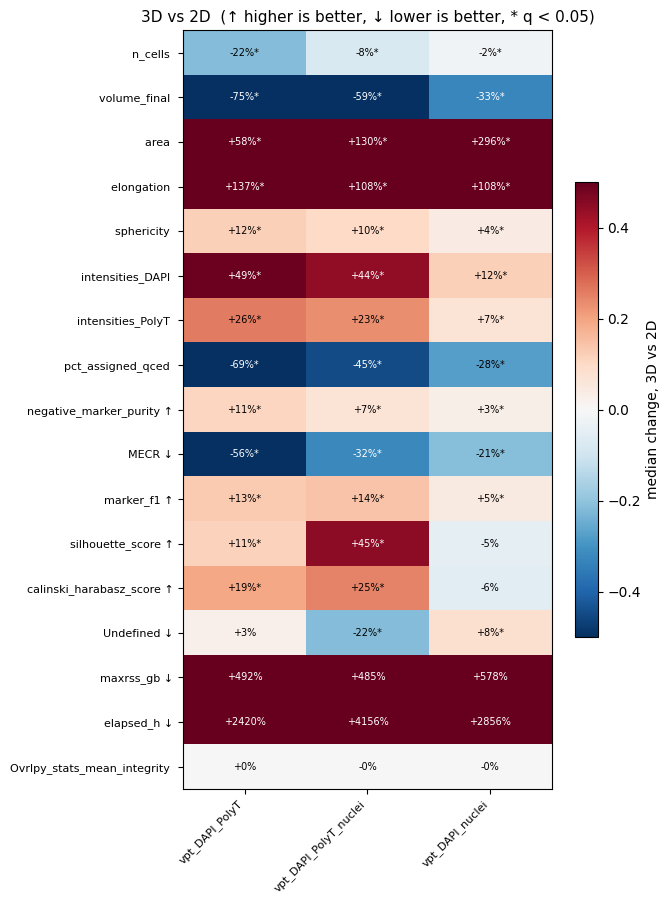

In [2]:
summary = pairs.groupby(["metric", "twin"]).agg(
    n=("change", "size"), change=("change", "median"),
    p=("change", lambda x: wilcoxon(x).pvalue if len(x) >= 5 and x.any() else np.nan)).reset_index()
tested = summary.p.notna()
summary.loc[tested, "q"] = false_discovery_control(summary.loc[tested, "p"])

twins = [m for m in method_colors if m in set(pairs.twin)]
found = set(summary.metric)
metrics = [m for m in order if m in found] + sorted(found - set(order))
change = summary.pivot(index="metric", columns="twin", values="change").loc[metrics, twins]
q = summary.pivot(index="metric", columns="twin", values="q").loc[metrics, twins]

fig, ax = plt.subplots(figsize=(0.9 * len(twins) + 4, 0.42 * len(metrics) + 2))
im = ax.imshow(change.clip(-0.5, 0.5), cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
for i, j in np.ndindex(change.shape):
    v = change.iat[i, j]
    if pd.notna(v):
        ax.text(j, i, f"{v:+.0%}{'*' if q.iat[i, j] < 0.05 else ''}", ha="center", va="center", fontsize=7,
                color="white" if abs(v) > 0.3 else "black")
ax.set_xticks(range(len(twins)), [method_names.get(twin_of[t], twin_of[t]) for t in twins], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(metrics)), [f"{metric_names.get(m, m)} {direction.get(m, '')}" for m in metrics], fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.6, label="median change, 3D vs 2D")
ax.set_title("3D vs 2D  (↑ higher is better, ↓ lower is better, * q < 0.05)", fontsize=11)
fig.tight_layout()

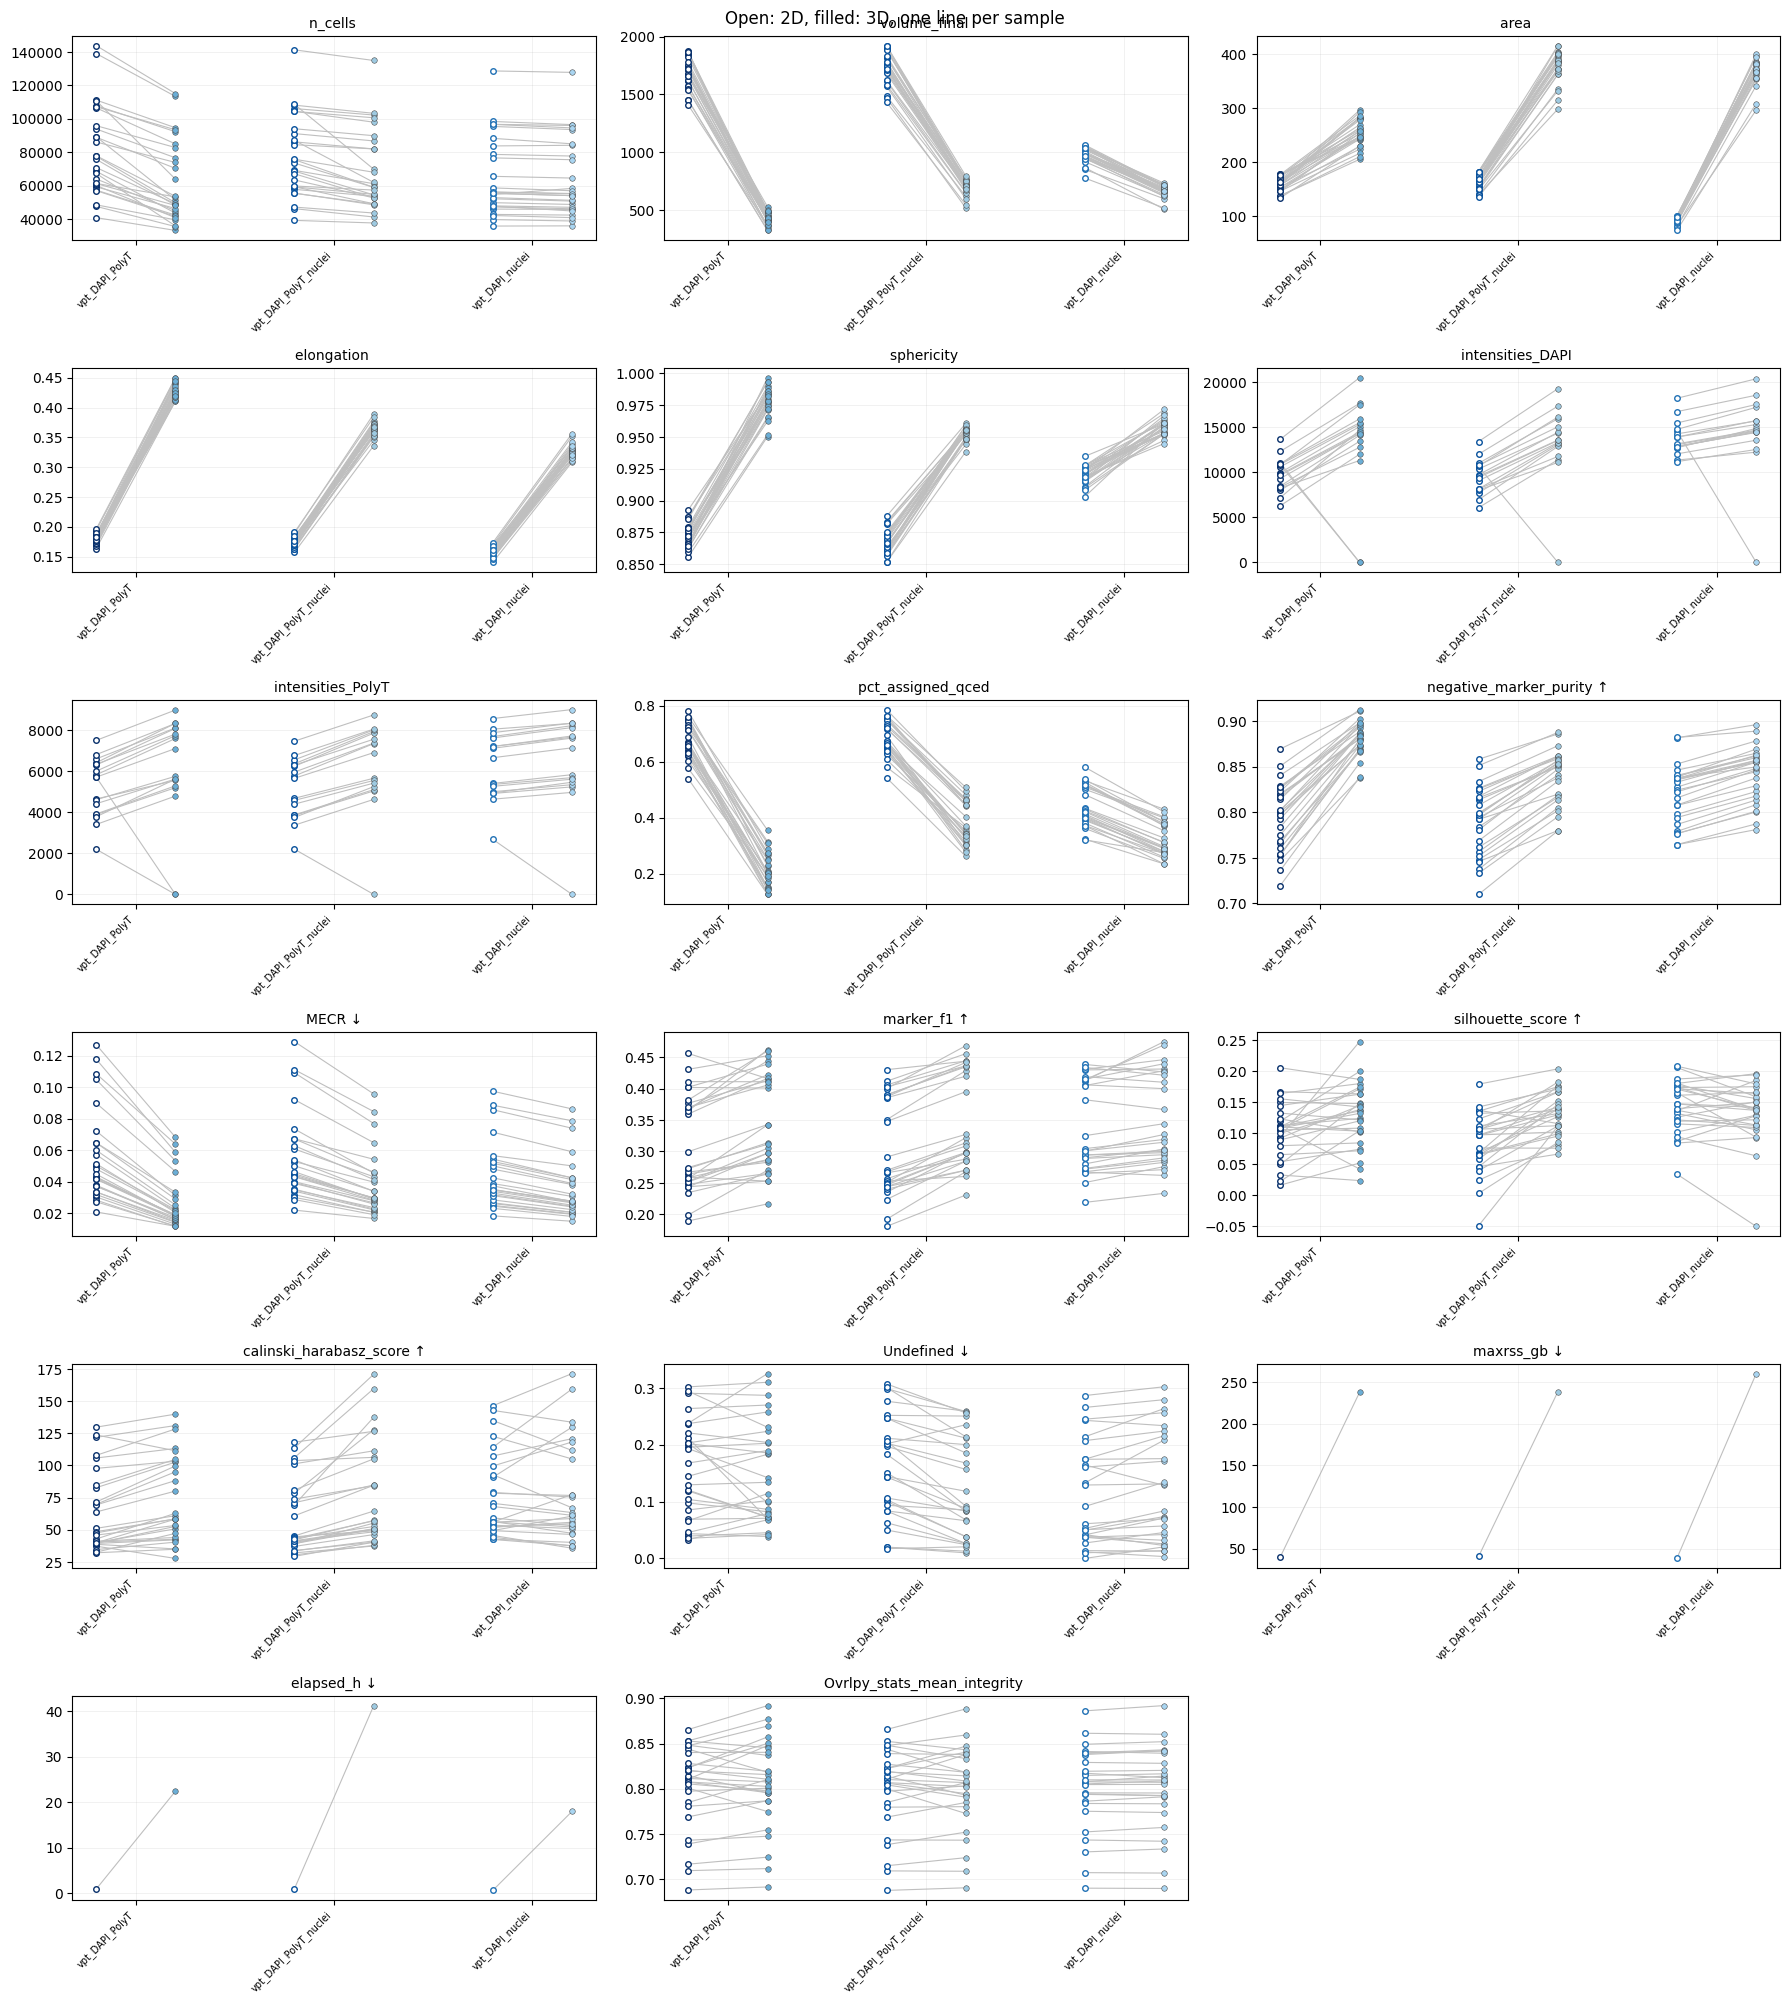

In [3]:
ncols = 3
nrows = -(-len(metrics) // ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.4 * nrows), squeeze=False)

for ax, metric in zip(axs.flat, metrics):
    d = pairs[pairs.metric == metric]
    for i, t in enumerate(twins):
        x = d[d.twin == t]
        if x.empty:
            continue
        ax.plot([i - 0.2, i + 0.2], x[["2D", "3D"]].T, color="0.75", lw=0.8, zorder=1)
        ax.scatter(np.full(len(x), i - 0.2), x["2D"], s=16, facecolor="white", edgecolor=color(twin_of[t]), zorder=2)
        ax.scatter(np.full(len(x), i + 0.2), x["3D"], s=16, color=color(t), edgecolor="0.3", lw=0.4, zorder=2)
    ax.set_xticks(range(len(twins)), [method_names.get(twin_of[t], twin_of[t]) for t in twins], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{metric_names.get(metric, metric)} {direction.get(metric, '')}", fontsize=10)
    ax.grid(alpha=0.25, lw=0.5)
for ax in axs.flat[len(metrics):]:
    ax.set_visible(False)
fig.suptitle("Open: 2D, filled: 3D, one line per sample", fontsize=12)
fig.tight_layout()